Varshini Narayanan

This code contains the analysis and visualizations for understanding stock comovement during stress days. Ai used for visualizations. 

436 lines of code



In [1]:
#import wrds
import pandas as pd
import numpy as np

In [ ]:
inst_data = pd.read_csv('str_vol_inst_data.csv')

In [24]:
# Convert date columns to datetime (because we need to filter by quarter)
inst_data['date'] = pd.to_datetime(inst_data['date'])

# Create quarter variable.
inst_data['quarter'] = inst_data['date'].dt.to_period('Q')

In [25]:
inst_data.head()

,ticker,date,daily_returns,mgrno,ownership_pct,shares,shrout,stress_day,quarter
0,AAPL,2018-01-02,0.017905,90457.0,0.068501,348468032.0,5.087056e+09,0,2018Q1
1,AAPL,2018-01-02,0.017905,9385.0,0.062849,319715585.0,5.087056e+09,0,2018Q1
2,AAPL,2018-01-02,0.017905,81540.0,0.041033,208739070.0,5.087056e+09,0,2018Q1
3,AAPL,2018-01-02,0.017905,8350.0,0.032501,165333962.0,5.087056e+09,0,2018Q1
4,AAPL,2018-01-02,0.017905,27800.0,0.023924,121704326.0,5.087056e+09,0,2018Q1


In [26]:
#get industry sectors

#%pip install yfinance

import yfinance as yf

unique_tickers = inst_data['ticker'].dropna().astype(str).unique()

sector_map = {}

for t in unique_tickers:
    try:
        info = yf.Ticker(t).info
        sector_map[t] = info.get("sector")
    except:
        sector_map[t] = None

print(sector_map)

{'AAPL': 'Technology', 'AMZN': 'Consumer Cyclical', 'ASML': 'Technology', 'AVGO': 'Technology', 'BAC': 'Financial Services', 'BRK': None, 'GOOG': 'Communication Services', 'JNJ': 'Healthcare', 'JPM': 'Financial Services', 'LLY': 'Healthcare', 'MA': 'Financial Services', 'META': 'Communication Services', 'MSFT': 'Technology', 'MU': 'Technology', 'NVDA': 'Technology', 'TSLA': 'Consumer Cyclical', 'TSM': 'Technology', 'V': 'Financial Services', 'WMT': 'Consumer Defensive', 'XOM': 'Energy'}


In [27]:
print(unique_tickers)

['AAPL' 'AMZN' 'ASML' 'AVGO' 'BAC' 'BRK' 'GOOG' 'JNJ' 'JPM' 'LLY' 'MA'
 'META' 'MSFT' 'MU' 'NVDA' 'TSLA' 'TSM' 'V' 'WMT' 'XOM']


In [79]:
import pandas as pd
import numpy as np

# Ensure date and quarter exist
inst_data['date'] = pd.to_datetime(inst_data['date'])
inst_data['quarter'] = inst_data['date'].dt.to_period('Q')

# Keep only stress days
inst_data = inst_data[inst_data['stress_day'] == 1].copy()

all_overlap_results = []

for q in inst_data['quarter'].unique():
    
    quarter_data = inst_data[inst_data['quarter'] == q].copy()
    
    # Skip quarters with fewer than 2 firms
    if quarter_data['ticker'].nunique() < 2:
        continue
    
    # Remove duplicate firm–institution pairs
    quarter_data = quarter_data.drop_duplicates(
        subset=['ticker', 'mgrno']
    )

    # Build firm × institution matrix
    firm_inst_matrix = quarter_data.pivot_table(
        index='ticker',
        columns='mgrno',
        values='ownership_pct',
        fill_value=0
    )
    
    # Convert to numpy array
    W = firm_inst_matrix.values
    
    # Compute weighted firm–firm overlap matrix
    overlap_matrix = W @ W.T
    
    overlap_df = pd.DataFrame(
        overlap_matrix,
        index=firm_inst_matrix.index,
        columns=firm_inst_matrix.index
    )
    
    # Remove self-overlap
    np.fill_diagonal(overlap_df.values, 0)
    
    # Convert to long format
    overlap_long = pd.DataFrame({
        'firm_i': np.repeat(overlap_df.index.values, len(overlap_df.columns)),
        'firm_j': np.tile(overlap_df.columns.values, len(overlap_df.index)),
        'ownership_overlap': overlap_df.values.flatten()
    })
    
    # Remove self-pairs and zero-overlap pairs
    overlap_long = overlap_long[
        (overlap_long['firm_i'] != overlap_long['firm_j']) &
        (overlap_long['ownership_overlap'] > 0)
    ]
    
    # Add quarter identifier
    overlap_long['quarter'] = q
    
    all_overlap_results.append(overlap_long)

# Combine all quarters
ownership_network = pd.concat(all_overlap_results, ignore_index=True)

/var/folders/vy/c51m8q751_72tx9f0b1r4blc0000gn/T/ipykernel_30483/1275919376.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inst_data['date'] = pd.to_datetime(inst_data['date'])
/var/folders/vy/c51m8q751_72tx9f0b1r4blc0000gn/T/ipykernel_30483/1275919376.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inst_data['quarter'] = inst_data['date'].dt.to_period('Q')


In [80]:
ownership_network = pd.concat(all_overlap_results, ignore_index=True)

print("Ownership network constructed successfully.")
print("Total observations:", len(ownership_network))
print(ownership_network.head())

Ownership network constructed successfully.
Total observations: 3840
  firm_i firm_j  ownership_overlap quarter
0   AAPL   AMZN           0.011249  2018Q1
1   AAPL   ASML           0.005714  2018Q1
2   AAPL    BAC           0.014709  2018Q1
3   AAPL    BRK           0.016220  2018Q1
4   AAPL   GOOG           0.011712  2018Q1


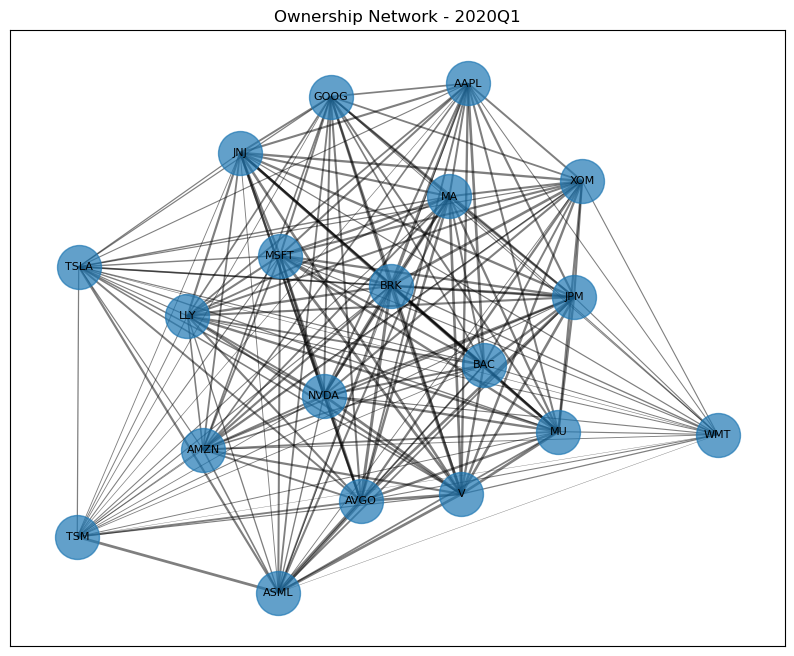

In [81]:
#vizualize network where Nodes = firms, Node size = weighted degree centrality, Edge thickness = ownership_overlap
import networkx as nx
import matplotlib.pyplot as plt

# Choose one representative quarter  out of 11 (chose 2020Q1)
q = '2020Q1'

q_data = ownership_network[ownership_network['quarter'] == q]

# Build graph
G = nx.Graph()

for _, row in q_data.iterrows():
    G.add_edge(row['firm_i'], row['firm_j'],
               weight=row['ownership_overlap'])

# Compute weighted degree centrality
centrality = dict(G.degree(weight='weight'))

# Draw
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=1)

nx.draw_networkx_nodes(
    G, pos,
    node_size= 1000,
    alpha=0.7
)

nx.draw_networkx_edges(
    G, pos,
    width=[G[u][v]['weight']*100 for u,v in G.edges()],
    alpha=0.5
)

nx.draw_networkx_labels(G, pos, font_size=8)
plt.title(f'Ownership Network - {q}')
plt.show()

/var/folders/vy/c51m8q751_72tx9f0b1r4blc0000gn/T/ipykernel_30483/51782799.py:31: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  edges = nx.draw_networkx_edges(


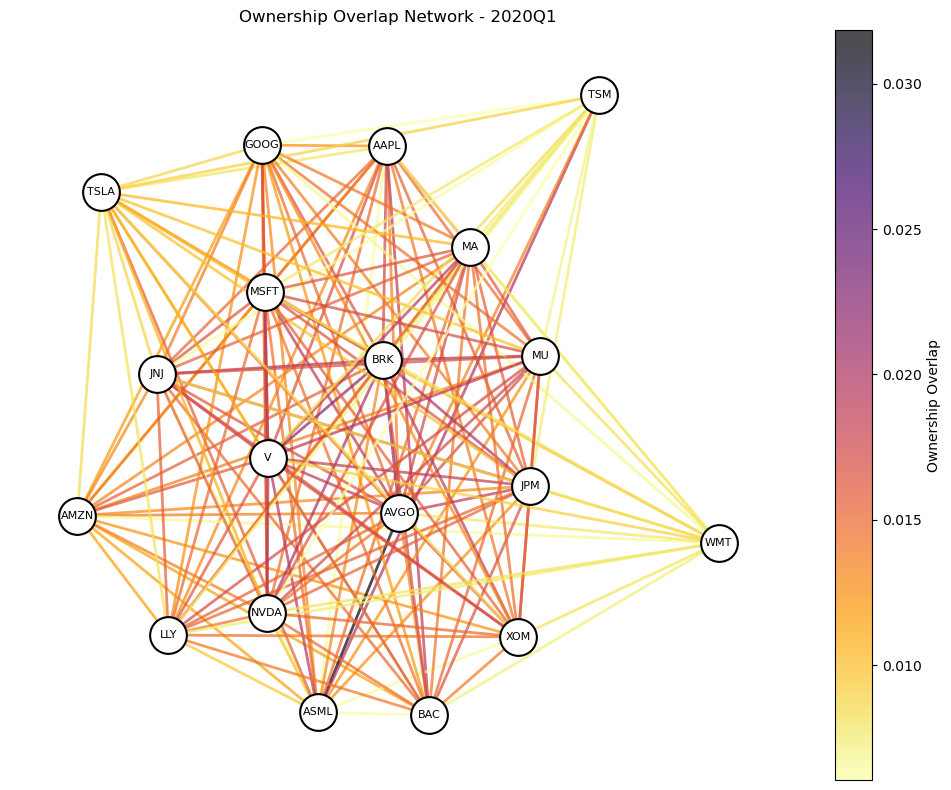

In [131]:
#updated visualization based on feedback
#vizualize network where Nodes = firms, Node size = weighted degree centrality, Edge thickness = ownership_overlap


# Choose quarter
q = '2020Q1'
q_data = ownership_network[ownership_network['quarter'] == q]

# filtering weak overlaps to reduce clutter
threshold = 0.006
q_data = q_data[q_data['ownership_overlap'] > threshold]

# Build graph
G = nx.Graph()
for _, row in q_data.iterrows():
    G.add_edge(row['firm_i'], row['firm_j'],
               weight=row['ownership_overlap'])

# Layout
pos = nx.spring_layout(G, seed=1, k=0.6)

# Extract edge weights
edge_weights = np.array([G[u][v]['weight'] for u, v in G.edges()])

# Scale edge widths
edge_widths = 1 + (edge_weights / edge_weights.max()) * 5.5

plt.figure(figsize=(10,8))

# Draw edges first (reversed colormap)
edges = nx.draw_networkx_edges(
    G, pos,
    width=2,
    edge_color=edge_weights,
    edge_cmap=plt.cm.inferno_r,
    connectionstyle='arc3,rad=0.08',
    alpha=0.7
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=700,
    node_color='white',
    edgecolors='black',
    linewidths=1.5
)

# Labels
nx.draw_networkx_labels(G, pos, font_size=8)

# Colorbar
plt.colorbar(edges, label='Ownership Overlap')

plt.title(f'Ownership Overlap Network - {q}')
plt.axis('off')
plt.tight_layout()
plt.show()

In [128]:
#descriptive stats for ownership overlap network (edge network)
# Ownership overlap descriptive statistics
overlap_stats = ownership_network['ownership_overlap'].describe()
print("Ownership Overlap Summary")
print(overlap_stats)

# Build network for a representative quarter (example: 2020Q1)
q = '2020Q1'
q_data = ownership_network[ownership_network['quarter'] == q]

G = nx.Graph()

for _, row in q_data.iterrows():
    G.add_edge(row['firm_i'], row['firm_j'], weight=row['ownership_overlap'])

# Network structure measures
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

avg_degree = sum(dict(G.degree()).values()) / num_nodes
avg_weighted_degree = sum(dict(G.degree(weight='weight')).values()) / num_nodes

clustering = nx.average_clustering(G, weight='weight')

print("\nNetwork Structure Statistics")
print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Density:", density)
print("Average Degree:", avg_degree)
print("Average Weighted Degree:", avg_weighted_degree)
print("Average Clustering:", clustering)

# Top ownership overlap pairs
top_pairs = ownership_network.sort_values(
    'ownership_overlap', ascending=False
).head(10)

print("\nTop Ownership Overlap Firm Pairs")
print(top_pairs[['firm_i','firm_j','ownership_overlap']])

Ownership Overlap Summary
count    3840.000000
mean        0.012826
std         0.004415
min         0.001916
25%         0.008999
50%         0.013841
75%         0.016038
max         0.036166
Name: ownership_overlap, dtype: float64

Network Structure Statistics
Nodes: 19
Edges: 171
Density: 1.0
Average Degree: 18.0
Average Weighted Degree: 0.23871735771707234
Average Clustering: 0.40476672433927213

Top Ownership Overlap Firm Pairs
     firm_i firm_j  ownership_overlap
362    AVGO   ASML           0.036166
344    ASML   AVGO           0.036166
1028   ASML   AVGO           0.031841
1046   AVGO   ASML           0.031841
686    ASML   AVGO           0.031747
704    AVGO   ASML           0.031747
47     ASML    TSM           0.024218
240     TSM   ASML           0.024218
1388   AVGO   ASML           0.023806
1370   ASML   AVGO           0.023806


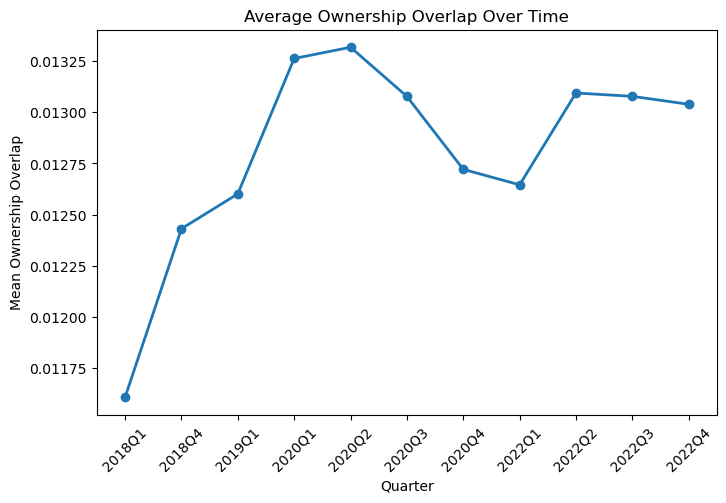

In [134]:
avg_overlap_time = ownership_network.groupby('quarter')['ownership_overlap'].mean()

plt.figure(figsize=(8,5))

plt.plot(
    avg_overlap_time.index.astype(str),
    avg_overlap_time.values,
    marker='o',
    linewidth=2
)

plt.title("Average Ownership Overlap Over Time")
plt.xlabel("Quarter")
plt.ylabel("Mean Ownership Overlap")
plt.xticks(rotation=45)

plt.show()

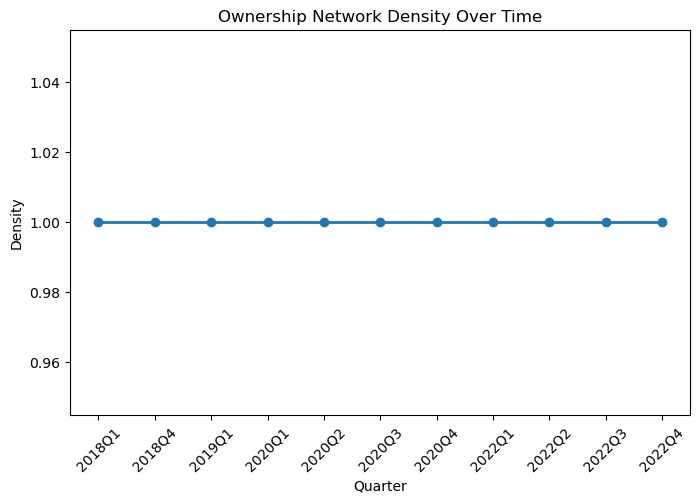

In [135]:
density_time = {}

for q in ownership_network['quarter'].unique():
    
    q_data = ownership_network[ownership_network['quarter'] == q]
    
    G = nx.Graph()
    
    for _, row in q_data.iterrows():
        G.add_edge(row['firm_i'], row['firm_j'], weight=row['ownership_overlap'])
    
    density_time[q] = nx.density(G)

density_df = pd.Series(density_time).sort_index()

plt.figure(figsize=(8,5))

plt.plot(
    density_df.index.astype(str),
    density_df.values,
    marker='o',
    linewidth=2
)

plt.title("Ownership Network Density Over Time")
plt.xlabel("Quarter")
plt.ylabel("Density")
plt.xticks(rotation=45)

plt.show()

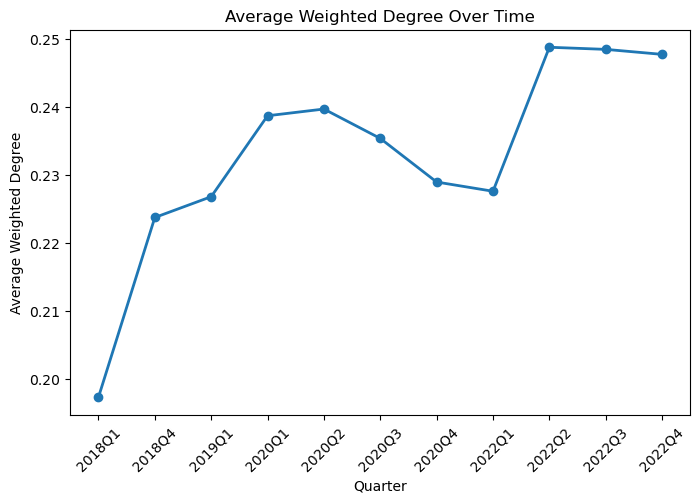

In [136]:
avg_weighted_degree_time = {}

for q in ownership_network['quarter'].unique():
    
    q_data = ownership_network[ownership_network['quarter'] == q]
    
    G = nx.Graph()
    
    for _, row in q_data.iterrows():
        G.add_edge(row['firm_i'], row['firm_j'], weight=row['ownership_overlap'])
    
    weighted_degree = dict(G.degree(weight='weight'))
    
    avg_weighted_degree_time[q] = sum(weighted_degree.values()) / len(weighted_degree)

avg_degree_df = pd.Series(avg_weighted_degree_time).sort_index()

plt.figure(figsize=(8,5))

plt.plot(
    avg_degree_df.index.astype(str),
    avg_degree_df.values,
    marker='o',
    linewidth=2
)

plt.title("Average Weighted Degree Over Time")
plt.xlabel("Quarter")
plt.ylabel("Average Weighted Degree")
plt.xticks(rotation=45)

plt.show()

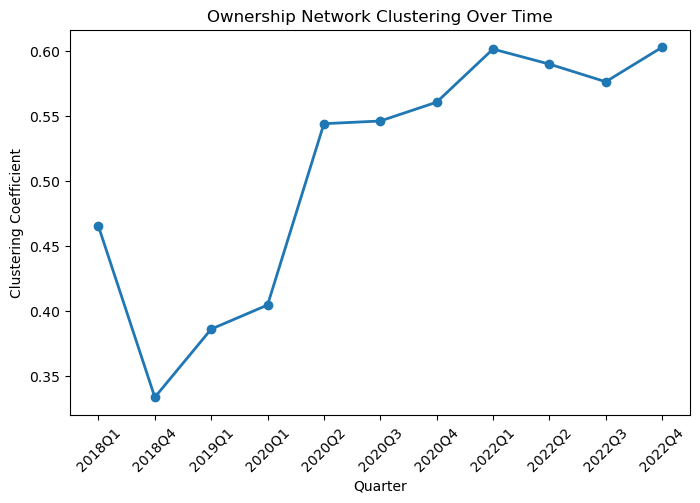

In [137]:
clustering_time = {}

for q in ownership_network['quarter'].unique():
    
    q_data = ownership_network[ownership_network['quarter'] == q]
    
    G = nx.Graph()
    
    for _, row in q_data.iterrows():
        G.add_edge(row['firm_i'], row['firm_j'], weight=row['ownership_overlap'])
    
    clustering_time[q] = nx.average_clustering(G, weight='weight')

clustering_df = pd.Series(clustering_time).sort_index()

plt.figure(figsize=(8,5))

plt.plot(
    clustering_df.index.astype(str),
    clustering_df.values,
    marker='o',
    linewidth=2
)

plt.title("Ownership Network Clustering Over Time")
plt.xlabel("Quarter")
plt.ylabel("Clustering Coefficient")
plt.xticks(rotation=45)

plt.show()

In [89]:
#compute correlations

inst_data['date'] = pd.to_datetime(inst_data['date'])
inst_data['quarter'] = inst_data['date'].dt.to_period('Q')

all_corr_results = []

for q in inst_data['quarter'].unique():
    
    q_data = inst_data[inst_data['quarter'] == q]
    
    # Pivot to date × firm matrix
    ret_matrix = q_data.pivot_table(
    index='date',
    columns='ticker',
    values='daily_returns'
    )

    # Remove firms with fewer than 2 observations
    ret_matrix = ret_matrix.dropna(axis=1, thresh=2)

    # Compute correlation matrix
    corr_matrix = ret_matrix.corr()
    
    # Convert to long format
    corr_long = pd.DataFrame({
        'firm_i': np.repeat(corr_matrix.index.values, len(corr_matrix.columns)),
        'firm_j': np.tile(corr_matrix.columns.values, len(corr_matrix.index)),
        'stress_correlation': corr_matrix.values.flatten()
    })
    
    # Remove self-correlations
    corr_long = corr_long[corr_long['firm_i'] != corr_long['firm_j']]
    
    corr_long['quarter'] = q
    
    all_corr_results.append(corr_long)

stress_corr_df = pd.concat(all_corr_results, ignore_index=True)

print(stress_corr_df.head())

  firm_i firm_j  stress_correlation quarter
0   AAPL   AMZN            0.710758  2018Q1
1   AAPL   ASML            0.588411  2018Q1
2   AAPL   AVGO            0.668191  2018Q1
3   AAPL    BAC            0.782746  2018Q1
4   AAPL    BRK            0.764748  2018Q1


In [90]:
#merge with ownership network
final_analysis = ownership_network.merge(
    stress_corr_df,
    on=['firm_i','firm_j','quarter'],
    how='inner'
)

print(final_analysis.head())

  firm_i firm_j  ownership_overlap quarter  stress_correlation
0   AAPL   AMZN           0.011249  2018Q1            0.710758
1   AAPL   ASML           0.005714  2018Q1            0.588411
2   AAPL    BAC           0.014709  2018Q1            0.782746
3   AAPL    BRK           0.016220  2018Q1            0.764748
4   AAPL   GOOG           0.011712  2018Q1            0.699523


In [91]:
#map sectors to both firms in pair
final_analysis["sector_i"] = final_analysis["firm_i"].map(sector_map)
final_analysis["sector_j"] = final_analysis["firm_j"].map(sector_map)

In [92]:
#create sector control
final_analysis["same_sector"] = (
    final_analysis["sector_i"] == final_analysis["sector_j"]
).astype(int)

In [93]:
final_analysis[['stress_correlation','ownership_overlap']].isna().sum()

stress_correlation    0
ownership_overlap     0
dtype: int64

In [94]:
#regression
import statsmodels.api as sm

X = sm.add_constant(final_analysis['ownership_overlap'])
y = final_analysis['stress_correlation']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     stress_correlation   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     107.9
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           6.55e-25
Time:                        18:27:56   Log-Likelihood:                -929.10
No. Observations:                3498   AIC:                             1862.
Df Residuals:                    3496   BIC:                             1875.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.3898      0.01

Stocks that share greater institutional ownership exhibit significantly higher return correlations during market stress periods. The estimated coefficient on ownership overlap is 12.54 (t = 10.38, p < 0.001), implying that a 1 percent increase in ownership overlap is associated with roughly a 0.125 increase in stress period correlation. While the model explains about 3% of the variation in pairwise correlations (R² = 0.03), the effect is economically meaningful and consistent with the hypothesis that shared institutional investors amplify comovement during market stress.

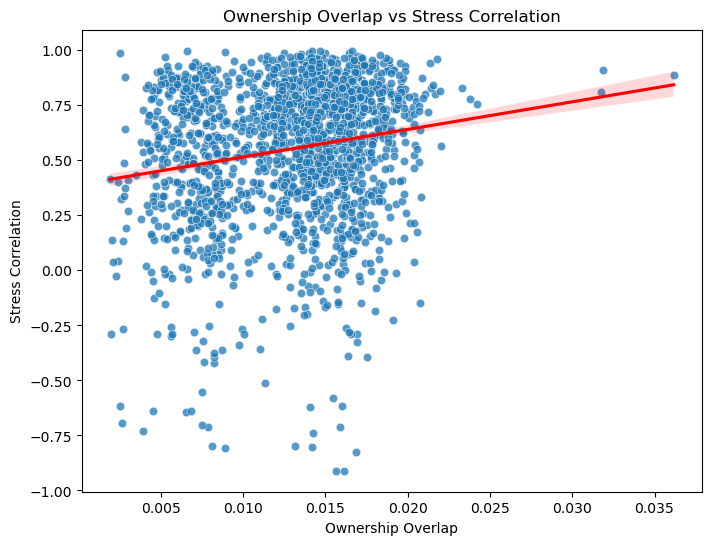

In [96]:
import seaborn as sns
#vizualize in scatterplot Ownership Overlap vs Stress Correlation
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='ownership_overlap',
    y='stress_correlation',
    data=final_analysis,
    alpha=0.5
)

sns.regplot(
    x='ownership_overlap',
    y='stress_correlation',
    data=final_analysis,
    scatter=False,
    color='red'
)

plt.title('Ownership Overlap vs Stress Correlation')
plt.xlabel('Ownership Overlap')
plt.ylabel('Stress Correlation')

plt.show()

The scatter plot shows a clear positive relationship between ownership overlap and stress-period correlation, with the fitted regression line sloping upward. However, there is substantial dispersion in correlations at lower levels of overlap, but the overall trend indicates that firm pairs with greater shared institutional ownership tend to show stronger comovement during stress, consistent with the estimated coefficient of 11.01.

/var/folders/vy/c51m8q751_72tx9f0b1r4blc0000gn/T/ipykernel_30483/151980850.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = final_analysis.groupby("overlap_bin")["stress_correlation"].mean().reset_index()
/var/folders/vy/c51m8q751_72tx9f0b1r4blc0000gn/T/ipykernel_30483/151980850.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_midpoints = final_analysis.groupby("overlap_bin")["ownership_overlap"].mean().values


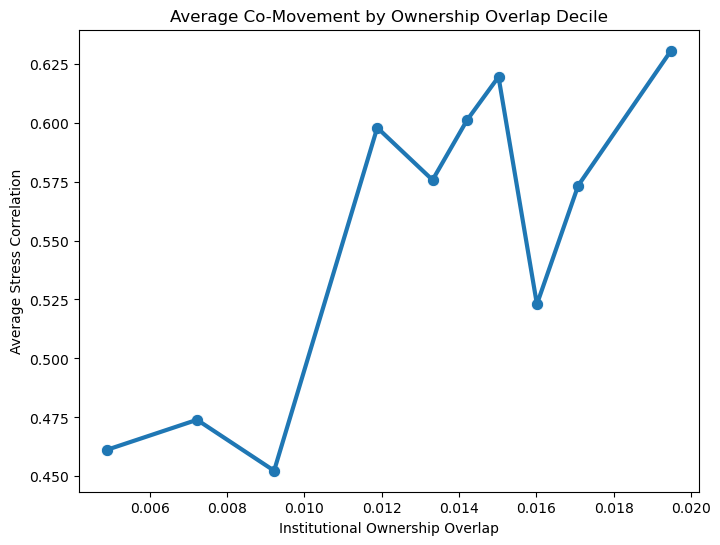

In [97]:
#bin data to show the average correlation within ownership-overlap groups (asked Ai how to clear visual)

final_analysis["overlap_bin"] = pd.qcut(final_analysis["ownership_overlap"], 10)

bin_means = final_analysis.groupby("overlap_bin")["stress_correlation"].mean().reset_index()
bin_midpoints = final_analysis.groupby("overlap_bin")["ownership_overlap"].mean().values

plt.figure(figsize=(8,6))

sns.scatterplot(x=bin_midpoints, y=bin_means["stress_correlation"], s=80)
sns.lineplot(x=bin_midpoints, y=bin_means["stress_correlation"], linewidth=3)

plt.xlabel("Institutional Ownership Overlap")
plt.ylabel("Average Stress Correlation")
plt.title("Average Co-Movement by Ownership Overlap Decile")

plt.show()

In [98]:
#regression with control 
X = final_analysis[["ownership_overlap", "same_sector"]]
X = sm.add_constant(X)

y = final_analysis["stress_correlation"]

model = sm.OLS(y, X).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     stress_correlation   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     292.9
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          2.53e-118
Time:                        18:29:33   Log-Likelihood:                -812.12
No. Observations:                3498   AIC:                             1630.
Df Residuals:                    3495   BIC:                             1649.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.3641      0.01

Even controlling for industry, we see that a 1 percent increase in institutional overlap is associated with a rougly .118 increase in stress period correlation. 

Next I look at a weighted degree based regression and network

In [104]:
#weighted degree based result

# degree centrality
degree_cent = nx.degree_centrality(G)

# weighted degree (measures the strength of connections)
weighted_degree = dict(G.degree(weight="weight"))

centrality_df = pd.DataFrame({
    "firm": list(degree_cent.keys()),
    "degree_centrality": list(degree_cent.values()), #also check degree centrality
    "weighted_degree": [weighted_degree[f] for f in degree_cent.keys()]
})

In [109]:
#merge into pair dataset 
final_analysis = final_analysis.merge(
    centrality_df[["firm","weighted_degree"]].rename(
        columns={"firm":"firm_i","weighted_degree":"weighted_degree_i"}
    ),
    on="firm_i",
    how="left"
)

final_analysis = final_analysis.merge(
    centrality_df[["firm","weighted_degree"]].rename(
        columns={"firm":"firm_j","weighted_degree":"weighted_degree_j"}
    ),
    on="firm_j",
    how="left"
)

In [110]:

#avg centrality
final_analysis["pair_centrality"] = (
    final_analysis["weighted_degree_x"] +
    final_analysis["weighted_degree_y"]
) / 2

In [111]:
#check for NAN and drop 
final_analysis[["pair_centrality","same_sector","stress_correlation"]].isna().sum()
reg_df = final_analysis[
    ["pair_centrality","same_sector","stress_correlation"]
].dropna()

In [112]:
import statsmodels.api as sm

X = reg_df[["pair_centrality", "same_sector"]]
X = sm.add_constant(X)

y = reg_df["stress_correlation"]

model_centrality = sm.OLS(y, X).fit(cov_type="HC3")

print(model_centrality.summary())

                            OLS Regression Results                            
Dep. Variable:     stress_correlation   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     304.7
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          2.24e-122
Time:                        18:33:08   Log-Likelihood:                -749.41
No. Observations:                3384   AIC:                             1505.
Df Residuals:                    3381   BIC:                             1523.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0449      0.038     

/var/folders/vy/c51m8q751_72tx9f0b1r4blc0000gn/T/ipykernel_30483/3354528929.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("centrality_bin")["stress_correlation"]


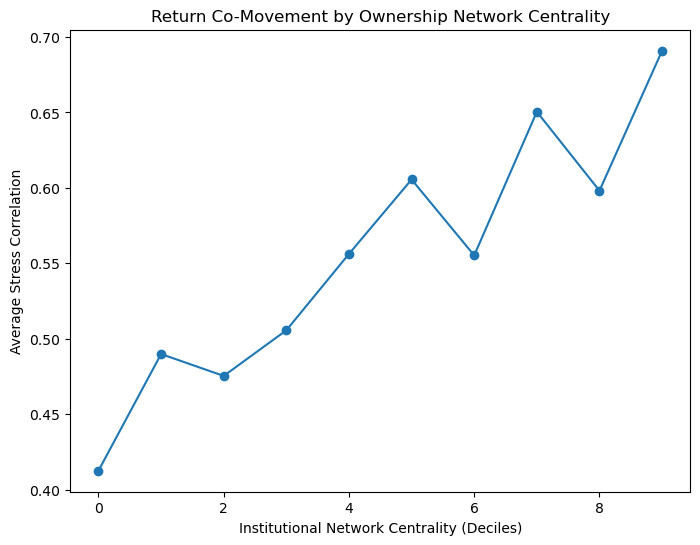

In [113]:

# create the centrality bins
final_analysis["centrality_bin"] = pd.qcut(final_analysis["pair_centrality"], 10)

# compute average correlation per bin
centrality_bins = (
    final_analysis
    .groupby("centrality_bin")["stress_correlation"]
    .mean()
    .reset_index()
)

# plot
plt.figure(figsize=(8,6))
plt.plot(range(len(centrality_bins)), centrality_bins["stress_correlation"], marker="o")

plt.xlabel("Institutional Network Centrality (Deciles)")
plt.ylabel("Average Stress Correlation")
plt.title("Return Co-Movement by Ownership Network Centrality")

plt.show()

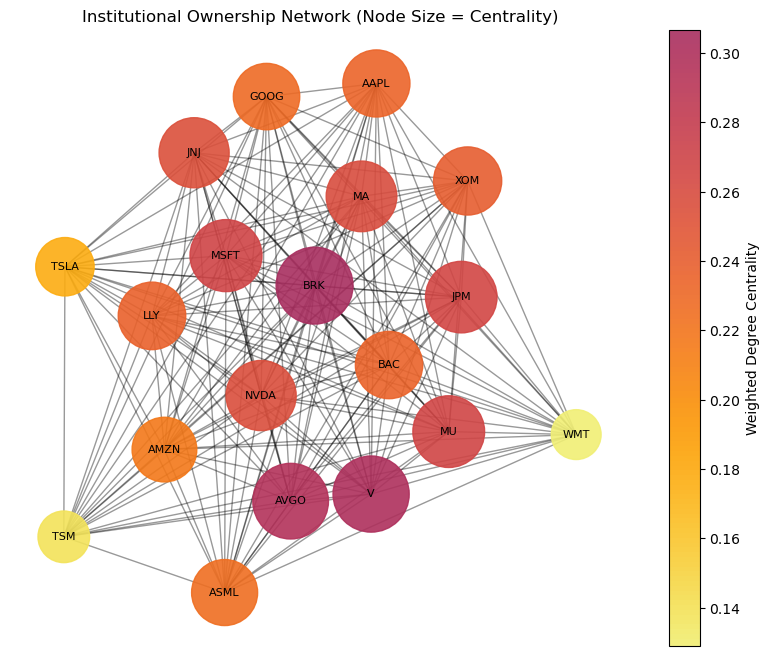

In [143]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Node sizes
node_sizes = [weighted_degree[node] * 10000 for node in G.nodes()]

# Node colors
node_colors = [weighted_degree[node] for node in G.nodes()]

# Truncated inferno that stops at purple
inferno_purple = mcolors.LinearSegmentedColormap.from_list(
    "inferno_purple",
    plt.cm.inferno(np.linspace(0.95, 0.45, 256))
)

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=1)

nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=inferno_purple,
    vmin=min(node_colors),     # control normalization
    vmax=max(node_colors),
    alpha=0.9
)

nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.colorbar(nodes, label="Weighted Degree Centrality")

plt.title("Institutional Ownership Network (Node Size = Centrality)")
plt.axis("off")
plt.show()

In [141]:
# descriptive stats for centrality network (node network)

# Build network for representative quarter
q = '2020Q1'
q_data = ownership_network[ownership_network['quarter'] == q]

G = nx.Graph()

for _, row in q_data.iterrows():
    G.add_edge(row['firm_i'], row['firm_j'], weight=row['ownership_overlap'])

# Compute weighted degree centrality
weighted_degree = dict(G.degree(weight='weight'))

centrality_df = pd.DataFrame({
    'firm': list(weighted_degree.keys()),
    'weighted_degree_centrality': list(weighted_degree.values())
})

# Centrality summary statistics
centrality_stats = centrality_df['weighted_degree_centrality'].describe()

print("Centrality Summary Statistics")
print(centrality_stats)

# Additional distribution measures
centrality_std = centrality_df['weighted_degree_centrality'].std()
centrality_median = centrality_df['weighted_degree_centrality'].median()

print("\nCentrality Distribution Measures")
print("Median Centrality:", centrality_median)
print("Centrality Standard Deviation:", centrality_std)

# Network centrality measures
max_centrality = centrality_df['weighted_degree_centrality'].max()
min_centrality = centrality_df['weighted_degree_centrality'].min()

print("\nNetwork Centrality Statistics")
print("Maximum Centrality:", max_centrality)
print("Minimum Centrality:", min_centrality)

# Top central firms
top_central_firms = centrality_df.sort_values(
    'weighted_degree_centrality',
    ascending=False
).head(10)

print("\nTop Central Firms")
print(top_central_firms)

Centrality Summary Statistics
count    19.000000
mean      0.238717
std       0.048259
min       0.128943
25%       0.227322
50%       0.240832
75%       0.266027
max       0.306666
Name: weighted_degree_centrality, dtype: float64

Centrality Distribution Measures
Median Centrality: 0.24083245322732258
Centrality Standard Deviation: 0.04825858866663514

Network Centrality Statistics
Maximum Centrality: 0.30666600906871516
Minimum Centrality: 0.1289434311361574

Top Central Firms
    firm  weighted_degree_centrality
5    BRK                    0.306666
16     V                    0.300729
3   AVGO                    0.296674
11  MSFT                    0.269021
12    MU                    0.266798
8    JPM                    0.265257
10    MA                    0.258702
13  NVDA                    0.255380
7    JNJ                    0.254768
18   XOM                    0.240832


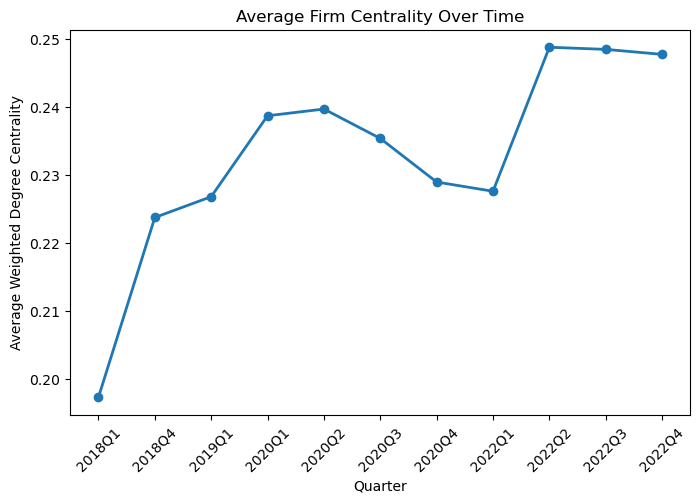

In [138]:
avg_centrality_time = {}

for q in ownership_network['quarter'].unique():
    
    q_data = ownership_network[ownership_network['quarter'] == q]
    
    G = nx.Graph()
    
    for _, row in q_data.iterrows():
        G.add_edge(row['firm_i'], row['firm_j'], weight=row['ownership_overlap'])
    
    weighted_degree = dict(G.degree(weight='weight'))
    
    avg_centrality_time[q] = sum(weighted_degree.values()) / len(weighted_degree)

avg_centrality_df = pd.Series(avg_centrality_time).sort_index()

plt.figure(figsize=(8,5))

plt.plot(
    avg_centrality_df.index.astype(str),
    avg_centrality_df.values,
    marker='o',
    linewidth=2
)

plt.title("Average Firm Centrality Over Time")
plt.xlabel("Quarter")
plt.ylabel("Average Weighted Degree Centrality")
plt.xticks(rotation=45)

plt.show()

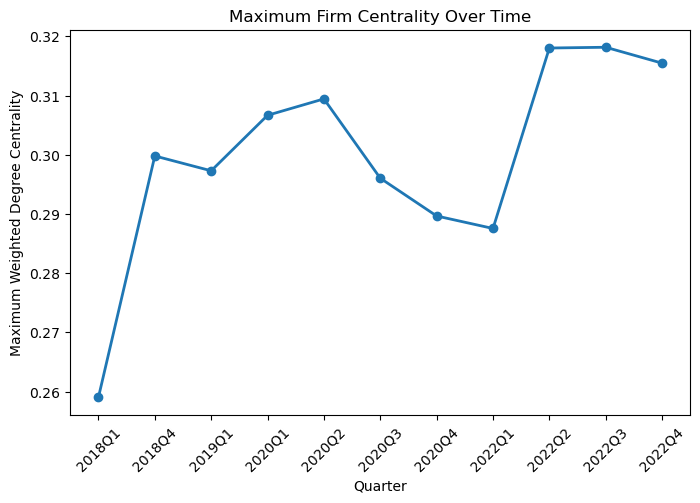

In [139]:
max_centrality_time = {}

for q in ownership_network['quarter'].unique():
    
    q_data = ownership_network[ownership_network['quarter'] == q]
    
    G = nx.Graph()
    
    for _, row in q_data.iterrows():
        G.add_edge(row['firm_i'], row['firm_j'], weight=row['ownership_overlap'])
    
    weighted_degree = dict(G.degree(weight='weight'))
    
    max_centrality_time[q] = max(weighted_degree.values())

max_centrality_df = pd.Series(max_centrality_time).sort_index()

plt.figure(figsize=(8,5))

plt.plot(
    max_centrality_df.index.astype(str),
    max_centrality_df.values,
    marker='o',
    linewidth=2
)

plt.title("Maximum Firm Centrality Over Time")
plt.xlabel("Quarter")
plt.ylabel("Maximum Weighted Degree Centrality")
plt.xticks(rotation=45)

plt.show()